In [1]:
# ==========================================================
# Task 3: Exploratory Data Analysis (EDA)
# Dataset: Netflix Movies and TV Shows
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("netflix_titles.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Records:")
print(df.head())

Dataset Shape: (8807, 12)

First 5 Records:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA

In [2]:
# ----------------------------------------------------------
# Dataset Information
# ----------------------------------------------------------

print("Dataset Information:")
print(df.info())

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary Statistics
print("\nSummary Statistics:")
print(df.describe(include='all'))

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3

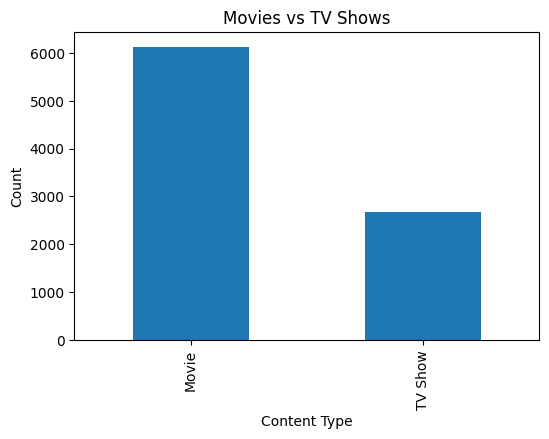

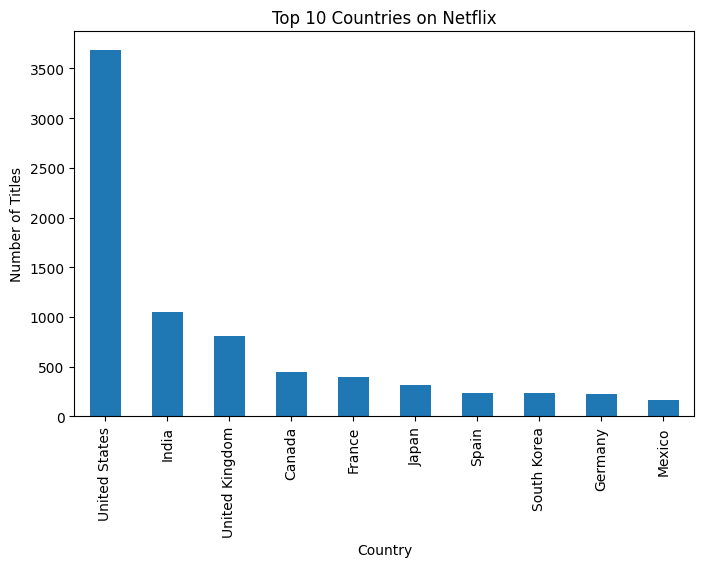

In [3]:
# ----------------------------------------------------------
# Movies vs TV Shows
# ----------------------------------------------------------

type_count = df["type"].value_counts()

plt.figure(figsize=(6,4))
type_count.plot(kind="bar")

plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()


# ----------------------------------------------------------
# Top 10 Countries Producing Netflix Content
# ----------------------------------------------------------

country_count = df["country"].dropna().str.split(', ').explode()

top_countries = country_count.value_counts().head(10)

plt.figure(figsize=(8,5))
top_countries.plot(kind="bar")

plt.title("Top 10 Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.show()

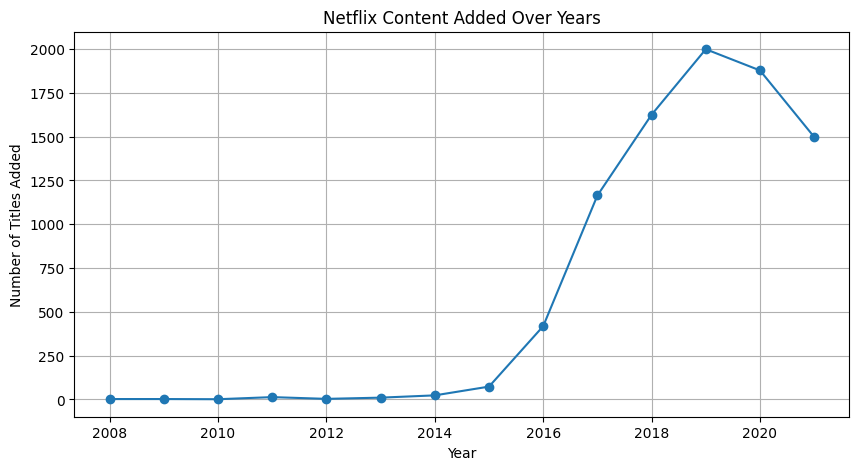


Correlation Matrix:
              release_year  year_added
release_year      1.000000    0.110473
year_added        0.110473    1.000000


In [4]:
# ----------------------------------------------------------
# Content Added Over the Years
# ----------------------------------------------------------

df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

df["year_added"] = df["date_added"].dt.year

yearly_content = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    yearly_content.index,
    yearly_content.values,
    marker='o'
)

plt.title("Netflix Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.grid(True)

plt.show()


# ----------------------------------------------------------
# Correlation Analysis
# ----------------------------------------------------------

numeric_df = df.select_dtypes(include=['int64','float64'])

if not numeric_df.empty:
    print("\nCorrelation Matrix:")
    print(numeric_df.corr())
else:
    print("\nNo significant numeric columns available for correlation analysis.")